---

## NOTEBOOK 3 Estadística inferencial

---

La inferencia estadística proporciona el marco formal para pasar del conocimiento parcial de una muestra hacia afirmaciones probabilísticas sobre la totalidad de la población, utiizando fundamentos de la estimación puntual, los métodos tradicionales de construcción de estimadores, nos garantizan la calidad de nuestras inferencias asi como la construcción e interpretación de intervalos de confianza.

## 1. Estimadores
 De acuerdo con el marco planteado por Mood et al., definimos como población al conjunto total de individuos, objetos o mediciones sobre los cuales deseamos realizar una indagación. \
 Matemáticamente, conceptualizamos a la población mediante una variable aleatoria $X$ cuya función de densidad (o de probabilidad) $f(x; \theta)$ depende de un parámetro desconocido $\theta \in \Theta$, donde $\Theta$ representa el espacio parametral.\
 Un parámetro $\theta$ es una constante fija pero desconocida que caracteriza a la distribución poblacional. Por ejemplo, la media poblacional $\mu = E[X]$ o la varianza poblacional $\sigma^2 = Var(X)$ son parámetros.\
  Dado que no podemos examinar a toda la población, extraemos una muestra aleatoria de tamaño $n$, denotada por la colección de variables aleatorias independientes e idénticamente distribuidas (i.i.d.) $X_1, X_2, \dots, X_n$.\
   Una vez recolectados los datos, observamos valores numéricos concretos $x_1, x_2, \dots, x_n$.Un estadístico es cualquier función de la muestra aleatoria que no contiene parámetros desconocidos, es decir, $T = g(X_1, X_2, \dots, X_n)$.\
Al ser función de variables aleatorias, el estadístico $T$ es, en sí mismo, una variable aleatoria con su propia distribución de probabilidad, conocida habitualmente como distribución muestral.Llamamos $estimador$ a un estadístico diseñado específicamente para aproximar el valor de un parámetro poblacional $\theta$.\
Denotamos a este estimador como $\hat{\Theta} = W(X_1, X_2, \dots, X_n)$. Es crucial enfatizar la distinción entre un estimador y una estimación: el estimador es la regla o función matemática (una variable aleatoria), mientras que la estimación es el valor numérico puntual $\hat{\theta} = W(x_1, x_2, \dots, x_x)$ que se obtiene al evaluar dicha función con una realización muestral concreta.

## Método de los Momentos

El Método de los Momentos, propuesto originalmente por Karl Pearson, es uno de los procedimientos más intuitivos para construir estimadores puntuales. Su fundamento teórico reside en el Principio de Analogía: sustituimos los momentos teóricos de la población por sus contrapartes empíricas obtenidas a partir de la muestra.

Definimos el $k$-ésimo momento poblacional alrededor del origen como:$$\mu_k = E[X^k] = g_k(\theta_1, \theta_2, \dots, \theta_m)$$Por otro lado, el $k$-ésimo momento muestral alrededor del origen se define como:$$M_k = \frac{1}{n} \sum_{i=1}^{n} X_i^k$$El método consiste en igualar los momentos poblacionales a los momentos muestrales para un sistema de $m$ ecuaciones con $m$ incógnitas:$$\mu_1(\theta_1, \dots, \theta_m) = M_1$$$$\mu_2(\theta_1, \dots, \theta_m) = M_2$$$$\vdots$$$$\mu_m(\theta_1, \dots, \theta_m) = M_m$$Resolviendo este sistema de ecuaciones simultáneas para los parámetros $\theta_1, \theta_2, \dots, \theta_m$, obtenemos los estimadores del método de momentos $\tilde{\theta}_1, \tilde{\theta}_2, \dots, \tilde{\theta}_m$.

### Ejemplo de derivación matemática:

Consideremos una muestra aleatoria $X_1, X_2, \dots, X_n$ proveniente de una distribución Gamma con parámetros de forma $\alpha$ y escala $\beta$, cuya función de densidad es:$$f(x; \alpha, \beta) = \frac{1}{\Gamma(\alpha) \beta^\alpha} x^{\alpha - 1} e^{-x/\beta}, \quad x > 0$$Sabemos por la teoría de probabilidades que los dos primeros momentos poblacionales corresponden a:$$\mu_1 = E[X] = \alpha \beta$$$$\mu_2 = E[X^2] = Var(X) + (E[X])^2 = \alpha \beta^2 + \alpha^2 \beta^2$$Igualando a los momentos muestrales $M_1 = \bar{X} = \frac{1}{n}\sum X_i$ y $M_2 = \frac{1}{n}\sum X_i^2$:$$\alpha \beta = \bar{X} \quad \Rightarrow \quad \beta = \frac{\bar{X}}{\alpha}$$Sustituyendo esta expresión en la segunda ecuación:$$\alpha \left(\frac{\bar{X}}{\alpha}\right)^2 + \alpha^2 \left(\frac{\bar{X}}{\alpha}\right)^2 = M_2$$$$\frac{\bar{X}^2}{\alpha} + \bar{X}^2 = M_2 \quad \Rightarrow \quad \frac{\bar{X}^2}{\alpha} = M_2 - \bar{X}^2 = S_m^2$$donde $S_m^2 = \frac{1}{n}\sum (X_i - \bar{X})^2$ es la varianza muestral sesgada. Despejando obtenemos los estimadores de momentos:$$\tilde{\alpha} = \frac{\bar{X}^2}{S_m^2}$$$$\tilde{\beta} = \frac{S_m^2}{\bar{X}}$$

Podemos hacer la simulación

--- PARÁMETROS REALES ---
Alpha real: 3.0000
Beta real:  2.0000

--- ESTIMADORES DE MOMENTOS (n = 1000) ---
Alpha estimado (α̃): 3.2163
Beta estimado (β̃):  1.9137


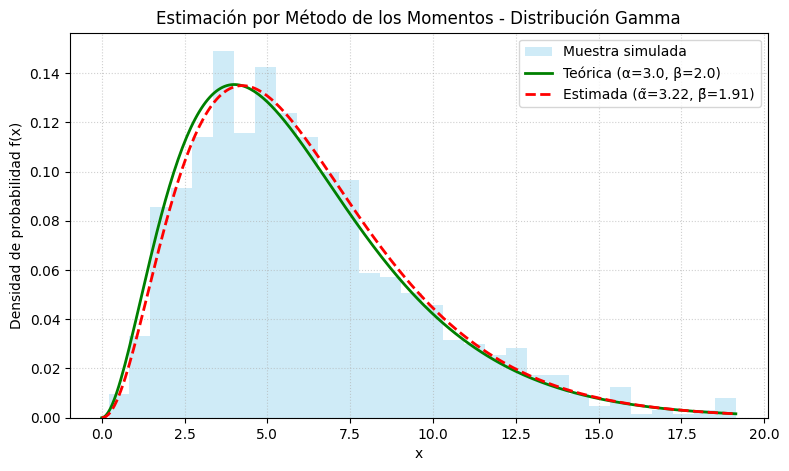

In [73]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

alpha_real = 3.0  # Parámetro de forma (shape)
beta_real = 2.0   # Parámetro de escala (scale)
n = 1000          # Tamaño de la muestra

np.random.seed(42)

muestra = np.random.gamma(shape=alpha_real, scale=beta_real, size=n)


X_bar = np.mean(muestra)                        # Media muestral (M1)
S2_m = np.var(muestra, ddof=0)                  # Varianza muestral sesgada (Sm^2)

alpha_hat = (X_bar**2) / S2_m                    # alpha estimado
beta_hat = S2_m / X_bar                         # beta estimado

print(f"--- PARÁMETROS REALES ---")
print(f"Alpha real: {alpha_real:.4f}")
print(f"Beta real:  {beta_real:.4f}\n")

print(f"--- ESTIMADORES DE MOMENTOS (n = {n}) ---")
print(f"Alpha estimado (α̃): {alpha_hat:.4f}")
print(f"Beta estimado (β̃):  {beta_hat:.4f}")

x_vals = np.linspace(0, max(muestra), 300)


pdf_real = stats.gamma.pdf(x_vals, a=alpha_real, scale=beta_real)

pdf_estimada = stats.gamma.pdf(x_vals, a=alpha_hat, scale=beta_hat)

plt.figure(figsize=(9, 5))
plt.hist(muestra, bins=30, density=True, alpha=0.4, color='skyblue', label='Muestra simulada')
plt.plot(x_vals, pdf_real, 'g-', lw=2, label=f'Teórica (α={alpha_real}, β={beta_real})')
plt.plot(x_vals, pdf_estimada, 'r--', lw=2, label=f'Estimada (α̃={alpha_hat:.2f}, β̃={beta_hat:.2f})')

plt.title('Estimación por Método de los Momentos - Distribución Gamma')
plt.xlabel('x')
plt.ylabel('Densidad de probabilidad f(x)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

## Estimador Máximo Verosimil



El método de Máxima Verosimilitud, formalizado por R. A. Fisher, busca responder a la siguiente pregunta:\
¿cuál es el valor del parámetro $\theta$ que hace que los datos observados sean lo más probables o creíbles posible?\

Sea $X_1, X_2, \dots, X_n$ una muestra aleatoria i.i.d. con densidad conjunta $f(x_1, \dots, x_n; \theta)$. La función de verosimilitud $L(\theta; \mathbf{x})$ se define reinterpretando la densidad conjunta como una función del parámetro $\theta$, dados los datos observados $\mathbf{x} = (x_1, \dots, x_n)$:$$L(\theta; \mathbf{x}) = \prod_{i=1}^{n} f(x_i; \theta)$$Debido a que el producto de densidades suele ser complejo de derivar, aplicamos la transformación monocromática del logaritmo natural para obtener la función de log-verosimilitud:$$\ell(\theta; \mathbf{x}) = \ln L(\theta; \mathbf{x}) = \sum_{i=1}^{n} \ln f(x_i; \theta)$$Para encontrar el Estimador de Máxima Verosimilitud (EMV), denotado por $\hat{\theta}_{EMV}$, derivamos la función de log-verosimilitud respecto a $\theta$, igualamos a cero la llamada ecuación de puntuación (score function):$$S(\theta) = \frac{\partial \ell(\theta; \mathbf{x})}{\partial \theta} = 0$$Para confirmar que hemos encontrado un máximo local y no un mínimo o punto de inflexión, verificamos la condición de segunda orden:$$\left. \frac{\partial^2 \ell(\theta; \mathbf{x})}{\partial \theta^2} \right\vert{}_{\theta = \hat{\theta}} < 0$$

### Ejemplo 1.

Lanzamod una moneda 100 veces, sabiendo que se obtienen 55 soles. Encontrar el EMV para la probabilidad $p$ de obtener sol en un solo lanzamiento.

Sea
$X$: el número de soles que se obtienen al lanzar una moneda
se tiene que $X\sim \text{Bin}(100,p)$, entonces

$$ f(x;p) = \binom{100}{55}p^{55}(1-p)^{100-55}$$

In [74]:
from scipy.stats import binom
import numpy as np

# Vamos a utilizar la libreria Sympy para matemática símbolica
import sympy

# importa la variable símbolica x
from sympy.abc import x

In [75]:
# Vamos a definir a p como una variable símbolica positiva: 0<p<1
p = sympy.symbols('p', positive= True)

# Definimos la función de verosimilitus
# se puede omitir la constante
f = p**55 * (1-p)**45

# Ahora derivamos f con respecto a p
df = sympy.diff(f,p)

# Hay que igualar la derivada a cero y despejar a p
# df=0 para encontrar p
phat = sympy.solve(df,p)[0] # [1] es la segunda solucion y [0] es la primera

print("El estimador de máxima verosimilitud es", phat)

El estimador de máxima verosimilitud es 11/20


La cual coincide con la proporción de soles.

### Ejemplo 2.
Vamos a simular una muestra de tamaño 100 de ceros y unos.

In [76]:
# n=1 : un ensayo de Bernoulli
# p : es la probabilidad de éxito
# size : genera 100 observaciones
r = binom.rvs(n=1, p=0.7, size = 100)
r

array([1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1])

In [77]:
# Vamos a calcular EMV

# Definimos la función de verosimilitud
f = p**x * (1-p)**(1-x)

# Calculamos el producto de todos los elementos
# subs(x,i) sustituye la variable símbolica x por una valor concreto de la muestra
J = np.prod([f.subs(x,i) for i in r])

# Calculamos el logJ de manera expandida
# sympy.log(J) = LogJ
logJ = sympy.expand_log(sympy.log(J))

# Calculamos da derivada e igualamos a cero
phat = sympy.solve(sympy.diff(logJ,p),p)[0]
print("El estimador de máxima verosimilitud es", phat)

El estimador de máxima verosimilitud es 4/5


In [78]:
# Podemos verificar  las soluciones con:
sol = sympy.solve(sympy.diff(logJ,p),p)
sol

[4/5]

### Ejemplo 3

El tiempo de retardo para pacientes con enfermedad coronaria potencial se define como la duración entre el comienzo de un síntoma agudo cardiovascular y la llegada a la unidad de emergencia.

Supongamos que el tiempo de retardo tiene una distribución exponencial de parámetro $\theta$.

Se tienen los siguientes registros de retardo (en minutos) en la clinica para los primeros 20 pacientes:

$$ 525, \ 719, \ 2880, \ 150, \ 30, \ 251, \ 45, \ 858, \ 15, \ 47, \ 90, \ 56, \ 68, \ 6, \ 189, \ 180, \ 60, \ 60, \ 294, \ 747 $$

- Encontrar el estimador por el método de momentos para la media
- Encontrar el valor del estimador con los datos.

Se tiene que
$$ X : \text{tiempo de retardo (en minutos)}$$
y que $X\sim\text{Exponencial}(\theta)$.

Recordemos que $\mathbb{E}[X]=1/\theta$ y y que $\text{Var}(X)= 1 /\theta^{2}$. Además el primer momento muestra es $\bar{X}$ y despejando a $\theta$ se tiene que
$$\hat{\theta} = 1/\bar{X}$$

In [79]:
# Ahora con los datos observados
datos = np.array([525, 719, 2880, 150, 30, 251, 45, 858, 15, 47, 90, 56, 68, 6, 189, 180, 60, 60, 294, 747])

# El tamaño de la muestra es
n = len(datos)

# Es estimador para la media muestral es
media_muestral = np.mean(datos)
print("La media muestral es", media_muestral)

La media muestral es 363.5


In [80]:
n

20

Se tiene que $\hat{\theta} = \frac{1}{\bar{X}} \approx 0.00275$ por minuto.

Por lo tanto, estimamos que el tiempo promedio de retardo entre el inicio de los sintomas cardiovasculares y la llegada a la unidad de emergencia es de aproximadamente 363.5 minutos.


### Ejercicio 3.

Suponga que la vida útil de los focos de cierta marca, se modela mediante una distribución exponencial de parámetro $\theta$ (es desconocido). Probamos 5 focos y encontramos que tienen una vida útil de $2,3,1,3$ y $5$ años respectivamente. Calcualar el EMV (MLE) para $\theta$.

In [81]:
# Datos:
datos = np.array([2,3,1,3,5])
n = len(datos)
media = np.mean(datos)
theta = 1 / media
print("La media es", media)
print("El estimador de máxima verosimilitus para θ es", theta)

La media es 2.8
El estimador de máxima verosimilitus para θ es 0.35714285714285715


Por lo tanto, la tasa estimada es de $0.3571$ fallas por año y se tiene que la vida media estimada de los focos es de 2.8 años.

**Ejercicio** Encontrar el estimador MLE con Sympy

In [82]:
import sympy as sp

theta = sp.Symbol('theta', positive=True)
n = sp.Symbol('n', positive=True, integer=True)
x = sp.IndexedBase('x')  # Para representar x_i
i = sp.Symbol('i', integer=True)

# Función de densidad f(x; theta) = theta * exp(-theta * x)
# Función de Verosimilitud (Likelihood): L(theta) = theta^n * exp(-theta * sum(x_i))
# Log-Verosimilitud (Log-Likelihood): ln L(theta) = n*ln(theta) - theta * sum(x_i)
sum_x = sp.Symbol('sum_x', positive=True) # representamos \sum x_i

log_L = n * sp.log(theta) - theta * sum_x

d_log_L = sp.diff(log_L, theta)
mle_expr = sp.solve(d_log_L, theta)[0]

print(f"Fórmula del estimador (MLE) de theta: {mle_expr}")


# Sustituir con los datos del problema
datos = [2, 3, 1, 3, 5]
n_val = len(datos)
sum_x_val = sum(datos)

theta_mle = mle_expr.subs({n: n_val, sum_x: sum_x_val})

print(f"Suma de los datos (∑x_i): {sum_x_val}")
print(f"Número de datos (n): {n_val}")
print(f"Estimador MLE para theta (exacto): {theta_mle}")
print(f"Estimador MLE para theta (decimal): {float(theta_mle):.16f}")

Fórmula del estimador (MLE) de theta: n/sum_x
Suma de los datos (∑x_i): 14
Número de datos (n): 5
Estimador MLE para theta (exacto): 5/14
Estimador MLE para theta (decimal): 0.3571428571428572


## 2. Propiedades de los Estimadores

### Insesgadez
 Decimos que un estimador $\hat{\Theta}$ es un estimador insesgado para el parámetro $\theta$ si el valor esperado de su distribución muestral es exactamente igual al parámetro verdadero que intenta estimar:$$E[\hat{\Theta}] = \theta, \quad \forall \, \theta \in \Theta$$El sesgo de un estimador se define como la diferencia entre su valor esperado y el parámetro real:$$Bias(\hat{\Theta}) = E[\hat{\Theta}] - \theta$$Si $Bias(\hat{\Theta}) = 0$, el estimador carece de desviaciones sistemáticas. Un caso ilustrativo clásico surge al comparar dos formas de calcular la varianza muestral:$$S_m^2 = \frac{1}{n}\sum_{i=1}^n (X_i - \bar{X})^2 \quad \text{vs.} \quad S^2 = \frac{1}{n-1}\sum_{i=1}^n (X_i - \bar{X})^2$$Se demuestra formalmente que $E[S_m^2] = \frac{n-1}{n}\sigma^2$, lo que revela que $S_m^2$ es un estimador sesgado que subestima sistemáticamente la variabilidad poblacional en muestras pequeñas.

 En cambio, dividir por $n-1$ corrige exactamente este desfase, haciendo que $E[S^2] = \sigma^2$.

### Consistencia
La insesgadez es una propiedad deseable para muestras fijas, pero también nos interesa el comportamiento asintótico cuando el tamaño muestral crece indefinidamente ($n \to \infty$).

Decimos que un estimador $\hat{\Theta}_n$ es consistente si converge en probabilidad hacia el verdadero parámetro $\theta$.

Formación matemática:$$\lim_{n \to \infty} P(\vert{}\hat{\Theta}_n - \theta\vert{} < \epsilon) = 1, \quad \forall \, \epsilon > 0$$Una condición suficiente para verificar la consistencia implica evaluar lo siguiente:
$\lim_{n \to \infty} E[\hat{\Theta}_n] = \theta$ (Insesgadez asintótica).

$\lim_{n \to \infty} Var(\hat{\Theta}_n) = 0$

La Ley Débil de los Grandes Números ampara la consistencia de la media muestral $\bar{X}_n$.

La consistencia es una garantía mínima: nos promete que conforme invirtamos recursos en recolectar muestras de mayor tamaño, el margen de error de nuestras estimaciones colapsará paulatinamente hacia cero, eliminando la incertidumbre muestral.

### Eficiencia y Cota Inferior de Cramér-Rao

Compara las varianzas relativas de los estimadores. Entre dos estimadores insesgados, el de menor varianza se considera más eficiente, ya que sus valores muestrales estarán más concentrados alrededor del verdadero parámetro.

La Cota Inferior de Cramér-Rao (CICR) establece un límite teórico mínimo para la varianza de cualquier estimador insesgado de $\theta$. Sea $X_1, \dots, X_n$ una muestra i.i.d. proveniente de una densidad $f(x; \theta)$ que satisface ciertas condiciones de regularidad (intercambio de derivadas e integrales).

La varianza de cualquier estimador insesgado $\hat{\Theta}$ está acotada por:$$Var(\hat{\Theta}) \ge \frac{1}{I_n(\theta)} = \frac{1}{n I_1(\theta)}$$donde $I_1(\theta)$ representa la Información de Fisher contenida en una sola observación, definida matemáticamente como:$$I_1(\theta) = E\left[ \left( \frac{\partial \ln f(X; \theta)}{\partial \theta} \right)^2 \right] = -E\left[ \frac{\partial^2 \ln f(X; \theta)}{\partial \theta^2} \right]$$Un estimador insesgado cuya varianza alcanza la Cota Inferior de Cramér-Rao se denomina estimador insesgado de varianza mínima o estimador totalmente eficiente, utilizar un estimador eficiente minimiza la amplitud de las equivocaciones inherentes al muestreo, ofreciendo decisiones con la máxima precisión teórica posible a partir de los mismos datos recolectados.

## Método de Monte Carlo
El concepto es simple: si no puedes calcular algo de forma analítica, "juega" a la probabilidad muchas veces y observa a qué valor tiende el promedio.

Imagina que alguien te pide calcular el área de una figura geométrica de forma tan irregular que ninguna fórmula conocida se aplica directamente. Un matemático buscaría una integral. Un estadístico haría algo completamente diferente: lanzaría dardos al azar y contaría cuántos caen dentro de la figura.

Esa intuición, aparentemente infantil, es la esencia del Método de Monte Carlo: resolver problemas deterministas — con una respuesta fija — mediante la generación masiva de números aleatorios.

Nacido en los laboratorios secretos de Los Álamos durante el Proyecto Manhattan, hoy es indispensable en finanzas cuantitativas, física de partículas, inteligencia artificial y ciencia de datos.

### El origen: Los Álamos y una baraja de cartas

En 1945, el matemático Stanislaw Ulam se encontraba en cama recuperándose de una enfermedad. Para pasar el tiempo jugaba solitario y se preguntó cuál era la probabilidad de ganar. Calcularla combinatoriamente era casi imposible, pero pensó: ¿qué pasa si simplemente juego cientos de partidas y cuento cuántas gano?

Compartió la idea con John von Neumann, quien la formalizó matemáticamente. Juntos, con Nicholas Metropolis, la aplicaron a los cálculos de difusión de neutrones para la bomba atómica. Necesitaban mantenerla en secreto, así que le dieron el nombre en código de Monte Carlo en alusión al famoso casino de Mónaco frecuentado por un tío de Ulam.

**“El primer programa de Monte Carlo corrió en la computadora ENIAC en 1948. Tardó horas en completar simulaciones que hoy toman milisegundos en un smartphone”.**

### Los fundamentos matemáticos

El método descansa sobre tres pilares teóricos sólidos de la probabilidad y la estadística: la **Ley de los Grandes Números**, el **Teorema Central del Límite**, y la **integración por muestreo**.

### La Ley de los Grandes Números

Si repetimos un experimento aleatorio muchas veces, el promedio de los resultados converge al valor esperado real. Formalmente, para variables aleatorias $X_1, X_2, ..., X_n$ independientes e idénticamente distribuidas con esperanza finita $\mu$:

> **LEY DÉBIL DE LOS GRANDES NÚMEROS**
> $$\bar{X}_n = (X_1 + X_2 + ... + X_n) / n \to \mu \quad \text{cuando} \quad n \to \infty$$

Esta ley es la garantía teórica de que nuestras simulaciones, si corremos suficientes iteraciones, convergerán al valor verdadero. Monte Carlo explota esta propiedad deliberadamente.

### El Teorema Central del Límite

Nos dice que la distribución del promedio muestral se aproxima a una **distribución normal**, sin importar la distribución original de los datos, a medida que $n$ crece. Esto nos permite construir intervalos de confianza para nuestras estimaciones Monte Carlo.

> **ERROR ESTÁNDAR DEL ESTIMADOR MONTE CARLO**
> $$\sigma / \sqrt{n} \approx \text{desviación estándar} / \sqrt{\text{número de simulaciones}}$$

Esta fórmula revela una verdad crítica: para reducir el error a la mitad, necesitamos cuatro veces más simulaciones. La convergencia de Monte Carlo es de orden $O(n^{-1/2})$, lo que lo hace robusto pero requiere potencia computacional.

### Integración por Monte Carlo

El uso más directo del método es calcular integrales que son analíticamente intratables. Dada una función $f(x)$, su integral en $[a, b]$ se estima como:

> **ESTIMADOR DE INTEGRAL MONTE CARLO**
> $$\int_{a}^{b} f(x) \, dx \approx (b - a) \cdot (1/N) \cdot \sum_{i} f(x_i)$$

Donde los $x_i$ son puntos uniformes en $[a, b]$.

### Anatomía de un algoritmo Monte Carlo

Todo método de Monte Carlo sigue la misma estructura en cuatro pasos:

  - **Definir el espacio de entrada**
    Identificar las variables aleatorias del problema y sus distribuciones de probabilidad (uniforme, normal, Poisson, etc.).
  - **Generar muestras aleatorias**
    Usar un generador de números pseudoaleatorios (PRNG) para samplear del espacio definido. La calidad del PRNG impacta directamente la confiabilidad del resultado.

  - **Ejecutar la función determinista**
    Evaluar el modelo o función para cada muestra generada.
    
  - **Agregar y analizar resultados**
     Calcular estadísticas (media, varianza, percentiles) sobre los resultados. Construir intervalos de confianza usando el TCL para cuantificar la incertidumbre.

### Ejemplo: Estimación de $\pi$
Imagina un cuadrado de lado $2r$ que contiene un círculo de radio $r$.
* El área del cuadrado es $(2r)^2 = 4r^2$.
* El área del círculo es $\pi r^2$.
* La razón entre las áreas es:
$$\frac{\text{Área del círculo}}{\text{Área del cuadrado}} = \frac{\pi r^2}{4r^2} = \frac{\pi}{4}$$

Por lo tanto:  $\pi \approx 4 \times \left( \frac{\text{Puntos dentro del círculo}}{\text{Total de puntos}} \right)$

### IMPLEMENTACIÓN EN PYTHON:

In [83]:
import numpy as np
import matplotlib.pyplot as plt

def estimar_pi(n_puntos):
    # Generar puntos aleatorios en un plano 2D entre -1 y 1
    x = np.random.uniform(-1, 1, n_puntos)
    y = np.random.uniform(-1, 1, n_puntos)

    # Calcular la distancia al origen para cada punto
    distancia_al_origen = x**2 + y**2

    # Un punto está dentro del círculo si x^2 + y^2 <= 1
    dentro_del_circulo = distancia_al_origen <= 1

    # Cálculo de pi
    puntos_dentro = np.sum(dentro_del_circulo)
    pi_estimado = 4 * puntos_dentro / n_puntos

    return x, y, dentro_del_circulo, pi_estimado

Resultados con 10000 puntos:
Valor estimado de π: 3.142
Error relativo: 0.0130%


<>:13: SyntaxWarning: invalid escape sequence '\p'
<>:13: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_1789/3228686072.py:13: SyntaxWarning: invalid escape sequence '\p'
  plt.title(f"Estimación de $\pi$ usando Monte Carlo ($n={n}$)")


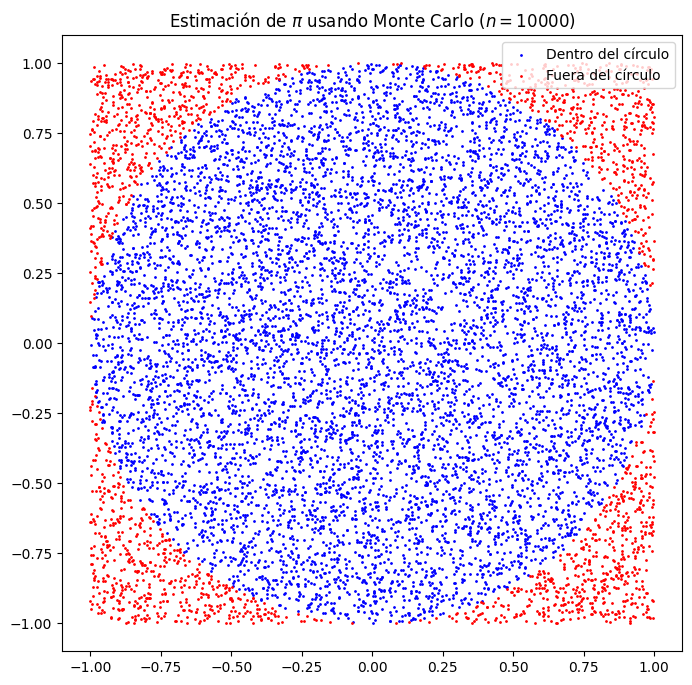

In [84]:
# Datos experimento
n = 10000
x, y, dentro, pi_final = estimar_pi(n) # dentro es un array booleano que indica si cada punto está dentro del círculo

print(f"Resultados con {n} puntos:")
print(f"Valor estimado de π: {pi_final}")
print(f"Error relativo: {abs(np.pi - pi_final) / np.pi * 100:.4f}%")

# Visualización
plt.figure(figsize=(8, 8))
plt.scatter(x[dentro], y[dentro], color='blue', s=1, label='Dentro del círculo')
plt.scatter(x[~dentro], y[~dentro], color='red', s=1, label='Fuera del círculo')
plt.title(f"Estimación de $\pi$ usando Monte Carlo ($n={n}$)")
plt.legend()
plt.show()

### Análisis de Convergencia

Una característica clave mencionada en el método es que la precisión aumenta con el número de iteraciones ($n$).

Vamos a ver como se "estabiliza" el valor:

<>:10: SyntaxWarning: invalid escape sequence '\p'
<>:13: SyntaxWarning: invalid escape sequence '\p'
<>:10: SyntaxWarning: invalid escape sequence '\p'
<>:13: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_1789/637861259.py:10: SyntaxWarning: invalid escape sequence '\p'
  plt.axhline(y=np.pi, color='r', linestyle='-', label='Valor real de $\pi$')
/tmp/ipykernel_1789/637861259.py:13: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('Valor de $\pi$ estimado')


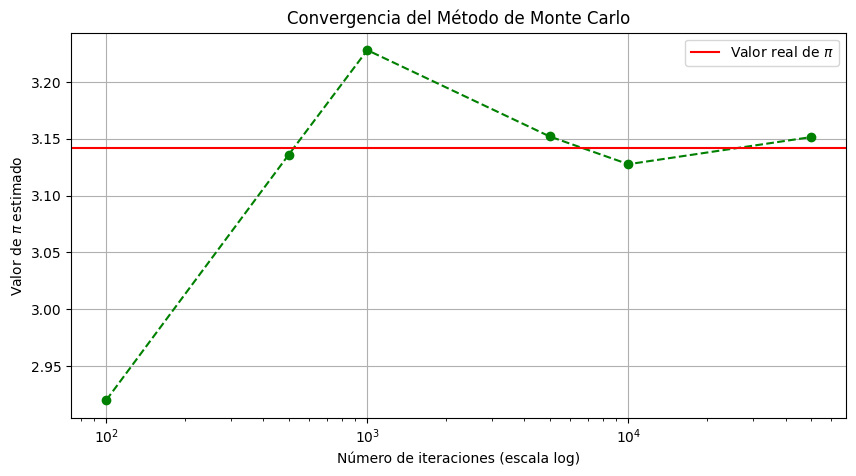

In [85]:
iteraciones = [100, 500, 1000, 5000, 10000, 50000]
resultados = []

for i in iteraciones:
    _, _, _, valor = estimar_pi(i)
    resultados.append(valor)

plt.figure(figsize=(10, 5))
plt.plot(iteraciones, resultados, marker='o', linestyle='--', color='green')
plt.axhline(y=np.pi, color='r', linestyle='-', label='Valor real de $\pi$')
plt.xscale('log')
plt.xlabel('Número de iteraciones (escala log)')
plt.ylabel('Valor de $\pi$ estimado')
plt.title('Convergencia del Método de Monte Carlo')
plt.legend()
plt.grid(True)
plt.show()

En el mundo de las finanzas, el **Método de Monte Carlo** se utiliza para modelar la incertidumbre y predecir el comportamiento de activos (como acciones) a lo largo del tiempo.

A diferencia de un cálculo lineal, aquí simulamos miles de "caminos" posibles que podría tomar el precio de una acción basándonos en su **volatilidad** y **rendimiento esperado**.

## Simulación de Monte Carlo para Predicción de Precios de Acciones

Utilizaremos el modelo de **Movimiento Browniano Geométrico (GBM)**. La fórmula simplificada para el cambio en el precio es:

$$\Delta S = S \times (\mu \Delta t + \sigma \epsilon \sqrt{\Delta t})$$

Donde:
* $S$: Precio de la acción.
* $\mu$: Rendimiento esperado (drift).
* $\sigma$: Volatilidad (riesgo).
* $\epsilon$: Variable aleatoria con distribución normal.

### Código de Implementación

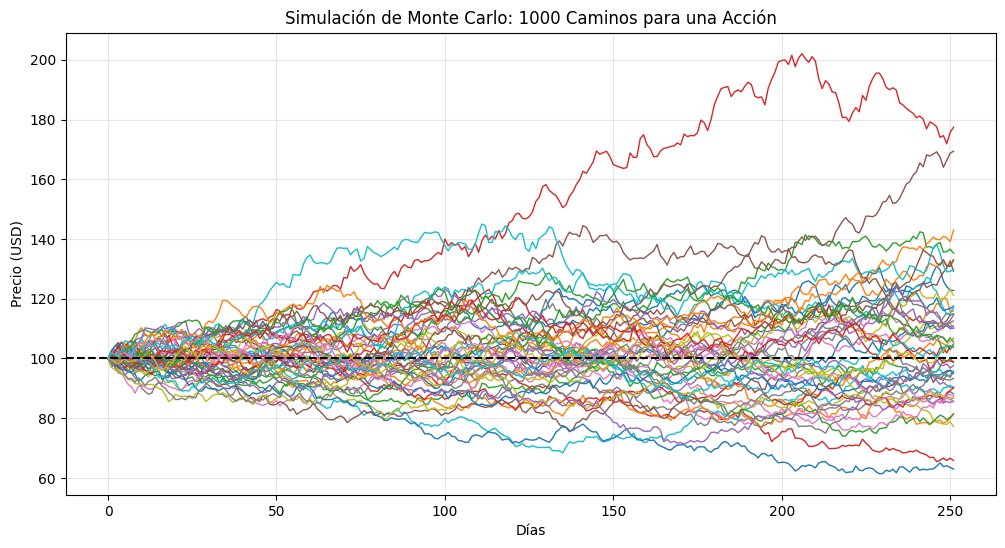

In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Parámetros de la simulación
precio_inicial = 100    # Precio actual de la acción (USD)
t_final = 252           # Días de trading en un año
mu = 0.1                # Rendimiento anual esperado (10%)
volatilidad = 0.2       # Volatilidad anual (20%)
n_simulaciones = 1000   # Número de escenarios posibles

# 2. Configuración de tiempos
dt = 1 / t_final
precios = np.zeros((t_final, n_simulaciones))
precios[0] = precio_inicial

# 3. Ejecución de la simulación
for t in range(1, t_final):
    # Generar números aleatorios (shocks del mercado)
    epsilon = np.random.standard_normal(n_simulaciones)

    # Calcular el precio para el siguiente paso de tiempo
    precios[t] = precios[t-1] * np.exp((mu - 0.5 * volatilidad**2) * dt +
                                        volatilidad * np.sqrt(dt) * epsilon)

# 4. Visualización de resultados
plt.figure(figsize=(12, 6))
plt.plot(precios[:, :50], lw=1) # Graficamos solo 50 rutas para no saturar
plt.axhline(y=precio_inicial, color='black', ls='--', label='Precio Inicial')
plt.title(f'Simulación de Monte Carlo: {n_simulaciones} Caminos para una Acción')
plt.xlabel('Días')
plt.ylabel('Precio (USD)')
plt.grid(True, alpha=0.3)
plt.show()

# 3. Intervalos de Confianza

### Fundamento teórico e inferencia por intervalo

Un intervalo de confianza aborda esta deficiencia de una estimación puntual reemplazando el valor único por un rango de valores plausibles construidos a partir de la distribución muestral del estimador.

Sea $X_1, \dots, X_n$ una muestra proveniente de una población con parámetro $\theta$. Un intervalo de confianza con nivel de confianza $(1-\alpha)$ está acotado por dos estadísticos $L(\mathbf{X})$ y $U(\mathbf{X})$ tales que:$$P(L(\mathbf{X}) \le \theta \le U(\mathbf{X})) = 1 - \alpha$$donde $\alpha \in (0, 1)$ representa la probabilidad de error o nivel de significancia (habitualmente $0.05$, $0.01$ o $0.10$).

La anchura del intervalo depende directamente de dos factores clave:
1. El Error Estándar (SE): La desviación estándar de la distribución muestral del estimador, que cuantifica la variabilidad intrínseca derivada del muestreo aleatorio.
2. El Margen de Error (ME): El producto entre un valor crítico derivado de la distribución de probabilidad correspondiente y el error estándar ($ME = Z_{\text{crit}} \times SE$).

### Intervalo de confianza para la media poblacional ($\mu$)

Para estimar el promedio de una variable en una población Normal $N(\mu, \sigma^2)$, distinguimos dos escenarios teóricos dependiendo de la información sobre la dispersión poblacional

### Caso 1: Varianza poblacional ($\sigma^2$) conocida

Por la propiedad de suma de variables normales independientes, la distribución muestral del promediador es:$$\bar{X} \sim N\left(\mu, \frac{\sigma^2}{n}\right)$$Estandarizando construimos la variable pivote:$$Z = \frac{\bar{X} - \mu}{\sigma / \sqrt{n}} \sim N(0, 1)$$Aislando el parámetro $\mu$ en la desmembración de la desigualdad de la probabilidad $P(-z_{\alpha/2} \le Z \le z_{\alpha/2}) = 1 - \alpha$, despejamos formalmente:$$\text{IC}_{(1-\alpha)}(\mu) = \left[ \bar{X} - z_{\alpha/2} \frac{\sigma}{\sqrt{n}}, \, \bar{X} + z_{\alpha/2} \frac{\sigma}{\sqrt{n}} \right]$$

### Caso 2: Varianza poblacional ($\sigma^2$) desconocida


En la inmensa mayoría de las aplicaciones prácticas no conocemos $\sigma^2$, por lo que debemos reemplazarla por la varianza muestral insesgada $S^2$. Al sustituir un parámetro por una estimación muestral, introducimos una fuente adicional de variabilidad.

Entonces tenemos que la variable transformada ya no sigue una distribución Normal estándar, sino una distribución t de Student con $v = n - 1$ grados de libertad :

$$T = \frac{\bar{X} - \mu}{S / \sqrt{n}} \sim t_{n-1}$$La estructura matemática del intervalo de confianza adopta la forma:$$\text{IC}_{(1-\alpha)}(\mu) = \left[ \bar{X} - t_{\alpha/2, \, n-1} \frac{S}{\sqrt{n}}, \, \bar{X} + t_{\alpha/2, \, n-1} \frac{S}{\sqrt{n}} \right]$$

### Ejemplo

Una empresa embotelladora de jugo en México desea auditar el volumen real entregado por sus máquinas llenadoras en presentaciones de 500 ml. Extraen una muestra aleatoria de $n = 16$ envases, obteniendo una media muestral de $\bar{X} = 495.2$ ml y una desviación estándar muestral de $S = 6.4$ ml. Asumiendo normalidad, calculamos un intervalo de confianza del 95% ($\alpha = 0.05$).

Simulación:

In [87]:
import numpy as np
import scipy.stats as stats

n = 16
media = 495.2
s = 6.4
confianza = 0.95
alpha = 1 - confianza


df = n - 1
t_critico = stats.t.ppf(1 - alpha/2, df)

# Error estándar y margen de error
se = s / np.sqrt(n)
margen_error = t_critico * se

ic_inferior = media - margen_error
ic_superior = media + margen_error

print(f"Valor crítico t (df={df}): {t_critico:.4f}")
print(f"Error Estándar (SE): {se:.4f}")
print(f"Margen de Error (ME): {margen_error:.4f}")
print(f"Intervalo de Confianza del 95%: [{ic_inferior:.4f}, {ic_superior:.4f}] ml")

Valor crítico t (df=15): 2.1314
Error Estándar (SE): 1.6000
Margen de Error (ME): 3.4103
Intervalo de Confianza del 95%: [491.7897, 498.6103] ml


Con un nivel de confianza del 95%, inferimos que el verdadero volumen promedio de llenado poblacional de todas las botellas procesadas por esta planta se encuentra dentro del rango comprendido entre $491.79$ ml y $498.61$ ml.

Entonces ¿esto que nos dice? que ya que el volumen nominal especificado de $500$ ml se halla por fuera y por encima de este intervalo, se cuenta con evidencia probabilística suficiente para concluir que las lineas de producción están operando con un sesgo sistemático de subllenado.

### Intervalo de confianza para una proporción poblacional ($p$)

Sea $X \sim \text{Binomial}(n, p)$, la proporción muestral se define como $\hat{p} = \frac{X}{n}$.

Sustentados en el Teorema del Límite Central, cuando el tamaño de muestra es suficientemente grande ($n p \ge 10$ y $n(1-p) \ge 10$), la distribución muestral de $\hat{p}$ se aproxima mediante una Normal $N\left(p, \frac{p(1-p)}{n}\right)$.

Sustituyendo el parámetro desconocido $p$ por la estimación puntual $\hat{p}$ en la desviación estándar, el intervalo de confianza tipo Wald para una proporción es:$$\text{IC}_{(1-\alpha)}(p) = \left[ \hat{p} - z_{\alpha/2} \sqrt{\frac{\hat{p}(1-\hat{p})}{n}}, \, \hat{p} + z_{\alpha/2} \sqrt{\frac{\hat{p}(1-\hat{p})}{n}} \right]$$

### Ejemplo

Un departamento de comercio electrónico realiza un estudio sobre la tasa de conversión de clientes. De una muestra aleatoria de $n = 500$ usuarios que navegaron por el sitio web, $x = 65$ realizaron una compra. Estimaremos la proporción real de conversión mediante un intervalo del 99% de confianza ($\alpha = 0.01$).

Simulación:

In [88]:
import numpy as np
import scipy.stats as stats

n = 500
x = 65
p_hat = x / n
confianza = 0.99
alpha = 1 - confianza

z_critico = stats.norm.ppf(1 - alpha/2)
se_prop = np.sqrt((p_hat * (1 - p_hat)) / n)
margen_error_prop = z_critico * se_prop

ic_inf_p = p_hat - margen_error_prop
ic_sup_p = p_hat + margen_error_prop

print(f"Proporción Muestral (p_hat): {p_hat:.4f}")
print(f"Valor Crítico Z (99%): {z_critico:.4f}")
print(f"Error Estándar: {se_prop:.4f}")
print(f"Intervalo para p: [{ic_inf_p:.4f}, {ic_sup_p:.4f}]")

Proporción Muestral (p_hat): 0.1300
Valor Crítico Z (99%): 2.5758
Error Estándar: 0.0150
Intervalo para p: [0.0913, 0.1687]


Con un 99% de confianza, estimamos que la proporción real de visitantes de la plataforma web que terminan realizando una transacción comercial se ubica entre un $9.13\%$ y un $16.87\%$. Esta información nos ayuda a los analistas financieros para proyectar ingresos.

# Conclusiones

En el análisis de datos no se reduce a aplicar fórmulas , sino que constituye un marco estructurado para tomar decisiones racionales bajo condiciones de incertidumbre.

La distinción entre la función matemática aleatoria que constituye un estimador y el valor numérico específico obtenido en una estimación me resultó deja en claro que la calidad del proceso estadístico radica en evaluar el método subyacente y no solo una cifra aislada.

Al analizar las metodologías para la construcción de estimadores,  comparar el Método de los Momentos con el Principio de Máxima Verosimilitud, nos dice que
1. El primero ofrece una alternativa altamente intuitiva, fácil de derivar algebraicamente y sumamente útil en la práctica cuando no tenemos certeza sobre la forma funcional detallada de la distribución subyacente.
2. La Máxima Verosimilitud destaca por su aprovechar toda la estructura de la función de densidad, genera estimadores con propiedades óptimas que minimizan la variabilidad muestral en muestras grandes.

La caracterización matemática de la insesgadez, la consistencia y la eficiencia me permite dimensionar los criterios de rigor que exige la teoría estadística.

El sesgo no siempre representa un defecto insuperable.

La diferencia fundamental entre obtener una cifra puntual estática y construir un margen de fluctuación fundamentado en el error estándar.

En sectores como las finanzas, la industria manufacturera o la ciencia de datos, los supuestos clásicos de normalidad, independencia y homogeneidad de varianza sufren distorsiones frecuentes debido a la presencia de sesgos de selección, valores atípicos o distribuciones de cola pesada. Por experiencia es imposible conocer todo el contexto antes de trabajar en ellos.

## Formulario:

a) Intervalo de confianza para la media $\mu$ de una distribución normal $N(\mu, \sigma)$ de varianza conocida $\sigma^2$

$$I = \left[ \bar{x} \pm z_{\alpha/2} \frac{\sigma}{\sqrt{n}} \right]$$

b) Intervalo de confianza para la media $\mu$ de una distribución normal $N(\mu, \sigma)$ de varianza desconocida $\sigma^2$

* Muestras superiores a 30, $n > 30 \quad \mapsto \quad I = \left[ \bar{x} \pm z_{\alpha/2} \frac{s}{\sqrt{n}} \right]$

* Muestras pequeñas $n \le 30 \quad \mapsto \quad I = \left[ \bar{x} \pm t_{\alpha/2; \, (n-1)} \frac{s}{\sqrt{n}} \right]$

c) Intervalo de confianza para la varianza $\sigma^2$ de una distribución normal

$$I = \left[ \frac{(n-1)s^2}{\chi_{\alpha/2; \, (n-1)}^2} \, ; \, \frac{(n-1)s^2}{\chi_{1-\alpha/2; \, (n-1)}^2} \right]$$

d) Intervalo de confianza para la diferencia de medias de dos distribuciones normales**

* Las varianzas poblacionales $\sigma_1^2$ y $\sigma_2^2$ son conocidas:

$$I = \left[ (\bar{x} - \bar{y}) \pm z_{\alpha/2} \sqrt{\frac{\sigma_1^2}{n_1} + \frac{\sigma_2^2}{n_2}} \right]$$

* Las varianzas poblacionales $\sigma_1^2$ y $\sigma_2^2$ son desconocidas:

  * Caso en que la suma $(n_1 + n_2) > 30$ con $n_1 \approx n_2$:

    $$I = \left[ (\bar{x} - \bar{y}) \pm z_{\alpha/2} \sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}} \right]$$

  * Caso en que los tamaños muestrales son pequeños y las varianzas son desconocidas, pero iguales:

    $$I = \left[ (\bar{x} - \bar{y}) \pm t_{\alpha/2; \, (n_1 + n_2 - 2)} \cdot s_p \sqrt{\frac{1}{n_1} + \frac{1}{n_2}} \right] \qquad s_p^2 = \frac{(n_1 - 1)s_1^2 + (n_2 - 1)s_2^2}{n_1 + n_2 - 2}$$

    *$s_p^2$ es la media ponderada de las cuasivarianzas muestrales*

  * Caso en que los tamaños muestrales son pequeños y las varianzas son desconocidas y distintas:

    $$I = \left[ (\bar{x} - \bar{y}) \pm t_{\alpha/2; \, f} \sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}} \right] \qquad \text{donde} \qquad f = \frac{\left( \frac{s_1^2}{n_1} + \frac{s_2^2}{n_2} \right)^2}{\frac{(s_1^2 / n_1)^2}{n_1 + 1} + \frac{(s_2^2 / n_2)^2}{n_2 + 1}} - 2$$

    *donde $f$ es la aproximación de Welch*

e) Intervalo de confianza para la razón de varianzas de dos poblaciones normales$$I = \left[ \frac{s_1^2 / s_2^2}{F_{\alpha/2; \; (n_1-1), \, (n_2-1)}} \; ; \; \frac{s_1^2 / s_2^2}{F_{1-\alpha/2; \; (n_1-1), \, (n_2-1)}} \right]$$$$\text{NOTA.- } F_{\alpha; \; n_1, \, n_2} = \frac{1}{F_{1-\alpha; \; n_2, \, n_1}}$$

f) Intervalo de confianza para el parámetro $p$ de una distribución binomial de parámetros $n, p, B(n, p)$

$$I = \left[ p_0 \pm z_{\alpha/2} \sqrt{\frac{p_0 (1 - p_0)}{n}} \right]$$

g) Intervalo de confianza para la diferencia de parámetros $(p_1 - p_2)$ de dos distribuciones binomiales$$I = \left[ (p_1 - p_2) \pm z_{\alpha/2} \sqrt{\frac{p_1 (1 - p_1)}{n_1} + \frac{p_2 (1 - p_2)}{n_2}} \right]$$

h) Intervalo de confianza para el parámetro $\lambda$ de una distribución de Poisson$$I = \left[ \lambda \pm z_{\alpha/2} \sqrt{\frac{\lambda}{n}} \right]$$

i) Intervalo de confianza para la diferencia de datos apareados

1. Para muestras grandes $n > 30$
$$I = \left[ \bar{d} \pm z_{\alpha/2} \frac{s_d}{\sqrt{n}} \right] \qquad \bar{d} = \frac{1}{n} \sum_{i=1}^{n} d_i \qquad d_i = \xi_i - \eta_i \qquad s_d^2 = \frac{1}{n-1} \sum_{i=1}^{n} (d_i - \bar{d})^2$$
2. Para muestras pequeñas $n < 30$
$$I = \left[ \bar{d} \pm t_{\alpha/2, \, (n-1)} \frac{s_d}{\sqrt{n}} \right]$$